In [14]:
import cv2
import time
import random
from random import sample

from matplotlib import pyplot as plt
import math
import os
import numpy as np

import mediapipe as mp
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler


In [15]:
align_file_test = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S1/align/bbaf2s.align" 


def ParseAlign(align_file: str)-> list[bool, int, int]:
    """
    Provides Clip information for a single .align file
    Args:
        align_file: path to align file
    Returns:
        clip_alignments: [[sil,start_frame,end_frame],[sil,start_frame end_frame],[talking,start_frame,end_frame],[talking,start_frame,end_frame]]
    """

    with open(align_file, 'r') as file:
        clip_alignment = []
        start_talk=0
        end_talk=0
        for line in file:
            alignment = line.strip('\n').split(" ")
            start, end, word = alignment
            if word == "sil":
                start_frame = math.ceil(int(start)*0.001)
                end_frame = math.ceil(int(end)*0.001)
                clip_alignment.append(["sil", start_frame, end_frame])
                
            else:
                if start_talk == 0:
                    start_talk = math.ceil(int(start)*0.001)
                if math.ceil(int(end)*0.001) > end_talk:
                    end_talk = math.ceil(int(end)*0.001)
        midpoint = math.ceil(start_talk + (end_talk-start_talk)/2)
        clip_alignment.append(["talking", start_talk, midpoint])
        clip_alignment.append(["talking", midpoint, end_talk])
            

    return clip_alignment

ParseAlign(align_file=align_file_test)

[['sil', 0, 13], ['sil', 51, 75], ['talking', 13, 32], ['talking', 32, 51]]

In [16]:
FULL_GRID_DIR = "/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata"

def ParseDataset(path: str) -> list[bool, int, int, str]:
    """Given a formatted dataset, returns all clip infromation
    Args:
        path: path to dataset
    Returns:
        clip_alignments: [istalking: bool,start_frame:int,end_frame:int, videopath:str]"""

    dataset_abstracted = []
    for subject in os.listdir(path):
        try:
            align_folder = path + "/" + subject + "/align"
            video_folder = path + "/" + subject + "/" + subject
            for filename in os.listdir(align_folder):
                video_clip_name = filename.split(".")[0]+".mpg"
                video_path = video_folder + "/"+ video_clip_name
                alignments = ParseAlign(align_folder+"/"+filename)
                if os.path.isfile(video_path): #Try video path except skip
                    for alignment in alignments:
                        clip_values = [*alignment, video_path]
                        dataset_abstracted.append(clip_values)

        except Exception as e:
            print("Exception Error:", e)

    return dataset_abstracted

dataset_values = ParseDataset(FULL_GRID_DIR)
print(dataset_values[0])



['sil', 0, 14, '/media/tymstr/Expansion/DiarizeDatabase/gridcorpusdata/S4/S4/bbae9n.mpg']


In [17]:
MOUTH_LANDMARKS = [0, 267, 269, 270, 409, 306, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61, 185, 40, 39,
                                37]

mpDraw = mp.solutions.drawing_utils
mpFaceMesh = mp.solutions.face_mesh
faceMesh = mpFaceMesh.FaceMesh(max_num_faces=2)
drawSpec = mpDraw.DrawingSpec(thickness=1, circle_radius=1)

def FindMouth(img, output_format):
    landmarks = []
    try:
        results = faceMesh.process(img)
        if results.multi_face_landmarks:
            for faceLms in results.multi_face_landmarks:
                # mpDraw.draw_landmarks(img, faceLms, mpFaceMesh.FACEMESH_CONTOURS, drawSpec, drawSpec)
                for id,lm in enumerate(faceLms.landmark):
                    image_height, image_width, image_channels = img.shape
                    x,y = int(lm.x*image_width), int(lm.y*image_height)
                    if output_format == "mouthrgb":
                        if id == 0:
                            return img[y-40:y+60,x-50:x+50,:]
                    if output_format == "liplandmarks":
                        if id in MOUTH_LANDMARKS:
                            landmarks.append((x,y))
            if landmarks:
                return landmarks
    except Exception as e:
        print("Failed to FindMouth:", e)
    return img
        

I0000 00:00:1742966533.233443  371832 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1742966533.320686  373753 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.120), renderer: NVIDIA GeForce RTX 4070/PCIe/SSE2
W0000 00:00:1742966533.325245  373744 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [18]:
# frameformats -> mouthrgb, mouthgreyscale, liplandmarks, fullframe/face



class FrameGenerator():
    """Given an array of dataset values, returns labeled and formatted data/frames"""
    def __init__(self, dataset_values, training=False, frame_format="mouthrgb"):
        self.dataset_values = dataset_values
        self.training = training
        self.frame_format = frame_format
        
        match self.frame_format:
            case "mouthrgb":
                self.input_shape = (10, 244, 244, 3)
            case "liplandmarks":
                self.input_shape = (10, 2, 20)
                


    def __call__(self):
        if self.training:
            np.random.shuffle(self.dataset_values) #Use a different shuffle method?
            # print((self.dataset_values[0]))

        # print("Test dataset format" ,self.dataset_values)
        for isTalking, start_frame, end_frame, video_path in self.dataset_values:
            label = np.int16(0 if isTalking == "sil" else 1) 
            formatted_frames = []

            cap = cv2.VideoCapture(video_path)
            count = 0
            while count < self.input_shape[0]:
                cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame+count)
                ret, frame = cap.read()
                if not ret:
                    print("failed to read: " + video_path + str(count))
                    # time.sleep(1)
                    formatted_frames.append(np.zeros((self.input_shape[1],self.input_shape[2], 3), dtype=np.float32))
                else:
                    frame = FindMouth(frame, self.frame_format)
                    if self.frame_format == "mouthrgb":
                        frame = frame / 255
                        
                        frame = tf.image.resize_with_pad(frame,self.input_shape[1],self.input_shape[2]) 
                        frame = tf.image.convert_image_dtype(frame, tf.float32)
                    if self.frame_format == "liplandmarks":
                        pass
                    formatted_frames.append(frame)
                count += 1

            cap.release()

            while len(formatted_frames) < 10:
                formatted_frames.append(np.zeros((self.input_shape[1], self.input_shape[2], 3), dtype=np.float32))

            formatted_frames = np.array(formatted_frames, dtype=np.float32)
            # print(formatted_frames)
            if self.frame_format == "mouthrgb":
                formatted_frames = np.array(formatted_frames)[...,[2,1,0]]
            yield formatted_frames, label

    




print(len(dataset_values))
train_dataset_values = sample(dataset_values, 8000)
val_dataset_values = sample(dataset_values, 2000)
print(len(train_dataset_values), len(val_dataset_values))                    

fg = FrameGenerator(dataset_values, True)

first_item, label = next(fg())

print(first_item.shape, label)
# print(label)        

120000
8000 2000


W0000 00:00:1742966533.337576  373745 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


(10, 244, 244, 3) 1


In [19]:
# train_ds = train_ds.batch(2)
# val_ds = val_ds.batch(2)

input_shape = (10, 244, 244, 3)

output_signature = (tf.TensorSpec(shape = input_shape, dtype = tf.float32, name="frames"),
                    tf.TensorSpec(shape = (), dtype = tf.int16, name="labels"))
train_ds = tf.data.Dataset.from_generator(FrameGenerator(train_dataset_values, True),
                                          output_signature = output_signature)
val_ds = tf.data.Dataset.from_generator(FrameGenerator(val_dataset_values, True),
                                          output_signature = output_signature)

print(train_ds)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)
print(train_ds)
val_ds = val_ds.shuffle(1000).cache().prefetch(buffer_size = AUTOTUNE)

<_FlatMapDataset element_spec=(TensorSpec(shape=(10, 244, 244, 3), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(10, 244, 244, 3), dtype=tf.float32, name='frames'), TensorSpec(shape=(), dtype=tf.int16, name='labels'))>


In [20]:
train_ds = train_ds.batch(2)
val_ds = val_ds.batch(2)

# print("Frames shape:", frames.shape)  # Should be (10, 100, 100, 3)
# print("Labels:", labels)  # Should be a single int16 label
for i in range(10):
    print(train_ds.take(i))

<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int16, name=None))>
<_TakeDataset element_spec=(TensorSpec(shape=(None, 10, 244, 244, 3), 

In [21]:



# model = models.Sequential([

#     layers.Input(shape=input_shape),
#     # Input Layer
#     # (2+1)D Conv Block 1
#     layers.Conv3D(32, kernel_size=(1, 3, 3), padding='same', activation='relu'),
#     layers.Conv3D(32, kernel_size=(3, 1, 1), padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling3D(pool_size=(1, 2, 2)),

#     # (2+1)D Conv Block 2
#     layers.Conv3D(64, kernel_size=(1, 3, 3), padding='same', activation='relu'),
#     layers.Conv3D(64, kernel_size=(3, 1, 1), padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling3D(pool_size=(2, 2, 2)),

#     # (2+1)D Conv Block 3
#     layers.Conv3D(128, kernel_size=(1, 3, 3), padding='same', activation='relu'),
#     layers.Conv3D(128, kernel_size=(3, 1, 1), padding='same', activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling3D(pool_size=(2, 2, 2)),

#     # Global Feature Aggregation
#     layers.GlobalAveragePooling3D(),
#     layers.Dropout(0.5),

#     # Fully Connected Layer
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.3),

#     # Output Layer (Binary Classification)
#     layers.Dense(1, activation='sigmoid')  # Change from softmax to sigmoid
# ])
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, LSTM, Dropout, Concatenate
from tensorflow.keras.layers import Lambda

frame_input = Input(shape=input_shape)

base_model = MobileNetV2(input_shape=(244, 244, 3), include_top=False, weights='imagenet')

encoded_frames = []
for i in range(input_shape[0]):
    x = tf.keras.layers.Lambda(lambda x: x[:, i])(frame_input)
    x = base_model(x)
    x = Flatten()(x)
    encoded_frames.append(x)   

visual_features = Lambda(lambda x: tf.stack(x, axis=1))(encoded_frames)
visual_features = LSTM(128, return_sequences=False)(visual_features)
visual_features = Dense(64, activation='relu')(visual_features)

output = Dense(1, activation='sigmoid')(visual_features)

model = Model(inputs=[frame_input], outputs=output)

# Compile Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),  # Change loss function
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Model Summary
history = model.fit(train_ds, 
          epochs = 50,
          validation_data = val_ds,
          callbacks = tf.keras.callbacks.EarlyStopping(patience = 5, monitor = 'val_loss'))

/tmp/ipykernel_371832/240042354.py:41: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(244, 244, 3), include_top=False, weights='imagenet')
2025-03-26 05:22:25.331526: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 160.00MiB (rounded to 167772160)requested by op StatelessRandomUniformV2
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-03-26 05:22:25.331558: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2025-03-26 05:22:25.331570: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 167, Chunks in use: 167. 41.8KiB all

ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[81920,512] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:StatelessRandomUniformV2] name: 

In [9]:
model.save_weights('./test.weights.h5')

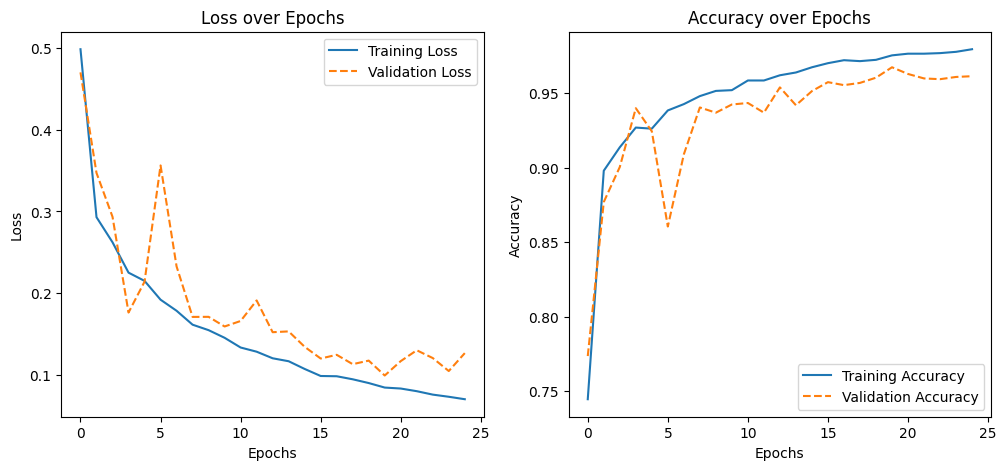

In [10]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()

# Call the function
plot_history(history)

In [11]:
for i in range(1, 10):
    next_item, label = next(fg())
    prediction = model.predict(next_item)
    print("Prediction:", prediction[0][0], "Label", label)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(10, 100, 100, 3), dtype=float32). Expected shape (None, 10, 100, 100, 3), but input has incompatible shape (10, 100, 100, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(10, 100, 100, 3), dtype=float32)
  • training=False
  • mask=None

In [11]:
# input_shape=(10, 100, 100, 3)
# input_data="Mouth_RGB"
# def ReadFrames(full_path: str, start, end, isTalking):
#     video = cv2.VideoCapture(full_path)
#     frames = []
#     count = 0
#     while count < input_shape[0] and count <= end:
#         video.set(cv2.CAP_PROP_POS_FRAMES, start+count)
#         ret, frame = video.read()
#         if not ret:
#             break
#             # continue
        

#     frames.append(frame)

    
#     res, frame = video.read()

#     if not res:
#         print("failed to read")
    
   
    # video.release()
# Given a file, start and end frame, produce a len10 array of frames